In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
import os, re, shutil

SAVE_DIR = "report_figures"
if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)      # wipe any stale files from earlier attempts
os.makedirs(SAVE_DIR, exist_ok=True)

_seen = {}
_original_show = plt.show

def _slugify(title):
    slug = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')
    return slug or "untitled"

def _auto_save_show(*args, **kwargs):
    fig = plt.gcf()
    title = ""
    for ax in fig.get_axes():
        t = ax.get_title()
        if t:
            title = t
            break
    slug = _slugify(title)
    _seen[slug] = _seen.get(slug, 0) + 1
    n = _seen[slug]
    filename = f"{slug}.png" if n == 1 else f"{slug}_{n}.png"
    fig.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')
    _original_show(*args, **kwargs)

plt.show = _auto_save_show

In [3]:
import os
print(os.listdir("report_figures"))

[]


In [4]:
df = pd.read_excel('online_retail_II.xlsx')

df.head(25)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


# Quick Sanity Checks and Metadata

In [5]:
df.columns
df = df.rename(columns={"Customer ID": "CustomerID"})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   CustomerID   417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,Price,CustomerID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [8]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
CustomerID     107927
Country             0
dtype: int64
Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
CustomerID     20.539488
Country         0.000000
dtype: float64


In [9]:
df.duplicated().sum()

np.int64(6865)

In [10]:
df = df.drop_duplicates()
df = df.dropna(subset=['Description']).copy()

In [11]:
# Creating flags

# Guest user flag
df['GuestFlag'] = df['CustomerID'].isna().astype(int)

# Return/Cancel flag
df['ReturnFlag'] = df['Invoice'].astype(str).str.startswith('C').astype(int)

# Valid sale = not return and quantity > 0
df['ValidSaleFlag'] = (
    (df['ReturnFlag'] == 0) &
    (df['Quantity'] > 0) &
    (df['Price'] > 0)
).astype(int)


In [12]:
# Convert CustomerID to int but keep NaN for guests
df['CustomerID'] = df['CustomerID'].astype('Int64')

print("Guest rows:", df['GuestFlag'].sum())
print("Returns:", df['ReturnFlag'].sum())
print("Valid sales:", df['ValidSaleFlag'].sum())

Guest rows: 104905
Returns: 10182
Valid sales: 504730


In [13]:
df.sample(n=50)  # 50 random rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,GuestFlag,ReturnFlag,ValidSaleFlag
389868,526890,21928,JUMBO BAG SCANDINAVIAN PAISLEY,100,2010-10-13 14:40:00,1.65,15032,United Kingdom,0,0,1
429822,530422,84968D,SET OF 16 VINTAGE RED CUTLERY,1,2010-11-03 09:36:00,25.49,<NA>,United Kingdom,1,0,1
152959,503933,22487,WHITE WOOD GARDEN PLANT LADDER,1,2010-04-08 13:54:00,9.95,18065,United Kingdom,0,0,1
64351,495102,85175,CACTI T-LIGHT CANDLES,32,2010-01-21 11:11:00,0.42,15547,United Kingdom,0,0,1
305984,519234,22180,RETRO SPOT LAMP,2,2010-08-15 13:18:00,9.95,17618,United Kingdom,0,0,1
271916,515773,22353,LUNCH BOX WITH CUTLERY FAIRY CAKES,10,2010-07-14 14:51:00,2.55,16161,United Kingdom,0,0,1
183986,506876,22169,FAMILY ALBUM WHITE PICTURE FRAME,2,2010-05-04 16:34:00,8.50,16526,United Kingdom,0,0,1
65696,495239,21544,SKULLS WATER TRANSFER TATTOOS,10,2010-01-22 10:01:00,1.66,<NA>,United Kingdom,1,0,1
398267,527455,22729,ALARM CLOCK BAKELIKE ORANGE,12,2010-10-18 10:20:00,3.75,17396,United Kingdom,0,0,1
285136,517095,21755,LOVE BUILDING BLOCK WORD,3,2010-07-26 14:43:00,5.95,16208,United Kingdom,0,0,1


In [14]:
# --- Step 1: Sanitize / fix column types ---

# Object/string columns
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['Description'] = df['Description'].astype(str)
df['Country'] = df['Country'].astype(str)

# Nullable integer column
df['CustomerID'] = df['CustomerID'].astype('Int64')

# Numeric columns
df['Quantity'] = df['Quantity'].astype(int)
df['Price'] = df['Price'].astype(float)

# Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515668 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        515668 non-null  object        
 1   StockCode      515668 non-null  object        
 2   Description    515668 non-null  object        
 3   Quantity       515668 non-null  int64         
 4   InvoiceDate    515668 non-null  datetime64[ns]
 5   Price          515668 non-null  float64       
 6   CustomerID     410763 non-null  Int64         
 7   Country        515668 non-null  object        
 8   GuestFlag      515668 non-null  int64         
 9   ReturnFlag     515668 non-null  int64         
 10  ValidSaleFlag  515668 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 47.7+ MB


# Descriptive Analysis

Sanity checks to make analysis reproducible and avoid hidden bugs.

In [16]:
# 1. Save a copy of cleaned dataframe so you never lose original.
df.to_parquet("cleaned_retail.parquet", index=False)


# 2. Sanity checks
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("Unique invoices:", df['Invoice'].nunique())
print("Unique products:", df['StockCode'].nunique())
print("Unique customers (registered):", df['CustomerID'].nunique())
print("Negative quantities:", (df['Quantity'] < 0).sum())
print("Zero or negative prices:", (df['Price'] <= 0).sum())


Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Unique invoices: 25888
Unique products: 4276
Unique customers (registered): 4383
Negative quantities: 10475
Zero or negative prices: 756


# Core Features Creation

In [17]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%Y-%m')
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

# filter for most descriptive metrics
df_all = df.copy()
df_sales = df.query("ValidSaleFlag == 1")
df_returns = df.query("ReturnFlag == 1")

# save prepared dataset for analysis stage
df_sales.to_parquet("df_sales.parquet", index=False)

High-level KPIs (executive summary)

In [18]:
# DESCRIPTIVE KPIs

# --- Non-merchandise SKUs to exclude ---
operational_skus = [
    'POST', 'DOT', 'M', 'BANK CHARGES', 'ADJUST',
    'C2', 'S', 'D', 'AMAZONFEE', 'gift_0001_80', 'TEST002'
]

# --- Filter to valid merchandise sales only ---
df_merch = df_sales[
    (~df_sales['StockCode'].isin(operational_skus)) &
    (df_sales['ValidSaleFlag'] == 1)
].copy()

# HIGH-LEVEL KPIs (Headline)

total_revenue = df_sales['TotalPrice'].sum()
total_units = df_sales['Quantity'].sum()
num_orders = df_sales['Invoice'].nunique()
headline_aov = total_revenue / num_orders

cust_orders = (
    df_sales
    .dropna(subset=['CustomerID'])
    .groupby('CustomerID')['Invoice']
    .nunique()
)

repeat_rate = (cust_orders > 1).mean()

print("=== Headline KPIs (All Transactions) ===")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Number of Orders: {num_orders:,}")
print(f"Headline AOV: ${headline_aov:,.2f}")
print(f"Repeat Customer Rate: {repeat_rate:.2%}")

# MERCHANDISE-ONLY KPIs

merch_revenue = df_merch['TotalPrice'].sum()
merch_orders = df_merch['Invoice'].nunique()
merch_aov = merch_revenue / merch_orders

# Order-level totals for distribution-aware metrics
order_values = (
    df_merch
    .groupby('Invoice')['TotalPrice']
    .sum()
)

median_order_value = order_values.median()

print("\n=== Merchandise-Only KPIs ===")
print(f"Merchandise Revenue: ${merch_revenue:,.2f}")
print(f"Merchandise Orders: {merch_orders:,}")
print(f"Merchandise AOV: ${merch_aov:,.2f}")
print(f"Median Merchandise Order Value: ${median_order_value:,.2f}")

# AOV BY CUSTOMER TYPE

aov_by_customer_type = (
    df_merch
    .groupby(['GuestFlag', 'Invoice'])['TotalPrice']
    .sum()
    .reset_index()
    .groupby('GuestFlag')['TotalPrice']
    .mean()
)

aov_by_customer_type.index = ['Registered', 'Guest']

print("\n=== AOV by Customer Type (Merch Only) ===")
print(aov_by_customer_type)

# GUEST vs REGISTERED SUMMARY

guest_order_summary = (
    df_merch
    .groupby(['GuestFlag', 'Invoice'])['TotalPrice']
    .sum()
    .reset_index()
    .groupby('GuestFlag')['TotalPrice']
    .agg(['sum', 'count', 'mean'])
)

guest_order_summary.columns = ['Revenue', 'Orders', 'AOV']
guest_order_summary.index = ['Registered', 'Guest']

print("\n=== Guest vs Registered Summary (Merch Only) ===")
print(guest_order_summary)

p90_order_value = order_values.quantile(0.90)


=== Headline KPIs (All Transactions) ===
Total Revenue: $10,271,762.66
Total Units Sold: 5,812,947
Number of Orders: 20,951
Headline AOV: $490.28
Repeat Customer Rate: 67.09%

=== Merchandise-Only KPIs ===
Merchandise Revenue: $9,806,616.59
Merchandise Orders: 20,585
Merchandise AOV: $476.40
Median Merchandise Order Value: $298.65

=== AOV by Customer Type (Merch Only) ===
Registered    455.296304
Guest         725.577679
Name: TotalPrice, dtype: float64

=== Guest vs Registered Summary (Merch Only) ===
                Revenue  Orders         AOV
Registered  8640613.264   18978  455.296304
Guest       1166003.330    1607  725.577679


Product-Level Analysis

In [19]:
# Merchandise only
df_merch = df_sales[~df_sales['StockCode'].isin(operational_skus)].copy()

# Operational SKUs only
df_operational = df_sales[df_sales['StockCode'].isin(operational_skus)].copy()

# Group by product and sum revenue
prod_rev_merch = (
    df_merch
    .groupby(['StockCode','Description'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values('TotalPrice', ascending=False)
)

# Top 20 merchandise products
top20_merch = prod_rev_merch.head(20)

# Bottom 20 merchandise products (excluding zero/negative revenue)
bottom20_merch = prod_rev_merch[prod_rev_merch['TotalPrice'] > 0].sort_values('TotalPrice').head(20)

print("=== TOP 20 MERCHANDISE PRODUCTS BY REVENUE ===")
print(top20_merch.to_string(index=False))

print("\n=== BOTTOM 20 MERCHANDISE PRODUCTS BY REVENUE ===")
print(bottom20_merch.to_string(index=False))

# Revenue from operational SKUs
op_revenue = df_operational['TotalPrice'].sum()
total_revenue = df_sales['TotalPrice'].sum()
op_pct = op_revenue / total_revenue * 100

print(f"\nRevenue from operational SKUs: ${op_revenue:,.2f} ({op_pct:.2f}% of total revenue)")


=== TOP 20 MERCHANDISE PRODUCTS BY REVENUE ===
StockCode                         Description  TotalPrice
    22423            REGENCY CAKESTAND 3 TIER   169912.76
   85123A  WHITE HANGING HEART T-LIGHT HOLDER   158305.72
    84879       ASSORTED COLOUR BIRD ORNAMENT    72890.19
    22086     PAPER CHAIN KIT 50'S CHRISTMAS     58127.30
   85099B             JUMBO BAG RED RETROSPOT    54368.82
    47566                       PARTY BUNTING    49664.12
    84347 ROTATING SILVER ANGELS T-LIGHT HLDR    47954.49
   15056N           EDWARDIAN PARASOL NATURAL    36251.10
    21621          VINTAGE UNION JACK BUNTING    36023.71
   85099F                JUMBO BAG STRAWBERRY    35887.14
    21232      STRAWBERRY CERAMIC TRINKET BOX    34411.68
   85099C      JUMBO  BAG BAROQUE BLACK WHITE    32055.82
  15056BL             EDWARDIAN PARASOL BLACK    31999.35
    21931              JUMBO STORAGE BAG SUKI    31493.71
    22189             CREAM HEART CARD HOLDER    31111.56
    79321                

In [20]:
# Step 1: Total sold units (positive) for merchandise only
sold_qty = df_sales[
    (~df_sales['StockCode'].isin(operational_skus)) &
    (df_sales['Quantity'] > 0)
].groupby(['StockCode','Description'])['Quantity'].sum().reset_index()
sold_qty = sold_qty.rename(columns={'Quantity':'SoldQty'})

# Step 2: Total returned units (absolute) from original df including returns
returned_qty = df[
    (~df['StockCode'].isin(operational_skus)) &
    (df['ReturnFlag']==1)
].groupby(['StockCode','Description'])['Quantity'].sum().abs().reset_index()
returned_qty = returned_qty.rename(columns={'Quantity':'ReturnedQty'})

# Step 3: Merge sold and returned
ret_rate = sold_qty.merge(returned_qty, on=['StockCode','Description'], how='left').fillna(0)

# Step 4: Compute return rate
ret_rate['ReturnRate_qty'] = ret_rate['ReturnedQty'] / ret_rate['SoldQty']

# Step 5: Filter out low-volume products (e.g., SoldQty < 5)
ret_rate_filtered = ret_rate[ret_rate['SoldQty'] >= 5].copy()

# Step 6: Flag anomalies (ReturnRate > 1) and cap at 1 for professional presentation
ret_rate_filtered['FlagHighReturn'] = ret_rate_filtered['ReturnRate_qty'] > 1
ret_rate_filtered['ReturnRate_qty'] = ret_rate_filtered['ReturnRate_qty'].clip(upper=1)

# Step 7: Sort by highest return rate
ret_rate_filtered = ret_rate_filtered.sort_values('ReturnRate_qty', ascending=False)

# Step 8: Top 50 merchandise by return rate
ret_rate_filtered.head(50)

,StockCode,Description,SoldQty,ReturnedQty,ReturnRate_qty,FlagHighReturn
336,20791,BLUE TILED SET OF 3 DRAWERS,5,5.0,1.000000,False
3213,79323B,BLACK CHERRY LIGHTS,234,240.0,1.000000,True
3219,79323S,SILVER CHERRY LIGHTS,60,153.0,1.000000,True
3221,79323W,WHITE CHERRY LIGHTS,978,1064.0,1.000000,True
267,20715,LITTLE FLOWER SHOPPER BAG,400,400.0,1.000000,False
398,20879,TREE OF NOAH FESTIVE SCENTED CANDLE,57,96.0,1.000000,True
2364,22850,BREAD BIN DINER STYLE BLACK,8,8.0,1.000000,False
2741,37471,MULTICOLOUR POLKADOT PLATE,684,684.0,1.000000,False
2207,22722,SET OF 6 SPICE TINS PANTRY DESIGN,6,6.0,1.000000,False
937,21496,WOODLAND CREATURES WRAP,25,25.0,1.000000,False


In [21]:
# Product profitability (proxy, because we dont have actual cost)
prod_stats = df_sales.groupby(['StockCode', 'Description']).agg(
    revenue=('TotalPrice', 'sum'),
    qty = ('Quantity', 'sum'),
    avg_price = ('Price', 'mean'),
    orders = ('Invoice', 'nunique')
).reset_index()

prod_stats['rev_per_qty'] = prod_stats['revenue'] / prod_stats['qty'].replace(0, np.nan)

prod_stats = prod_stats.sort_values('revenue', ascending=False)
prod_stats.head(20)

,StockCode,Description,revenue,qty,avg_price,orders,rev_per_qty
4717,M,Manual,262577.36,2764,473.651382,512,94.999045
1858,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,14.378958,2019,12.415985
4114,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3.048492,3281,2.711364
4716,DOT,DOTCOM POSTAGE,116408.71,730,159.463986,730,159.463986
3773,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1.995819,1412,1.611616
1457,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,3.367165,957,3.378512
4083,85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,2.169936,1222,1.792753
2884,47566,PARTY BUNTING,49664.12,10079,5.610272,1013,4.927485
4719,POST,POSTAGE,49477.54,2310,26.655191,759,21.418848
3367,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,23037,3.267682,347,2.081629


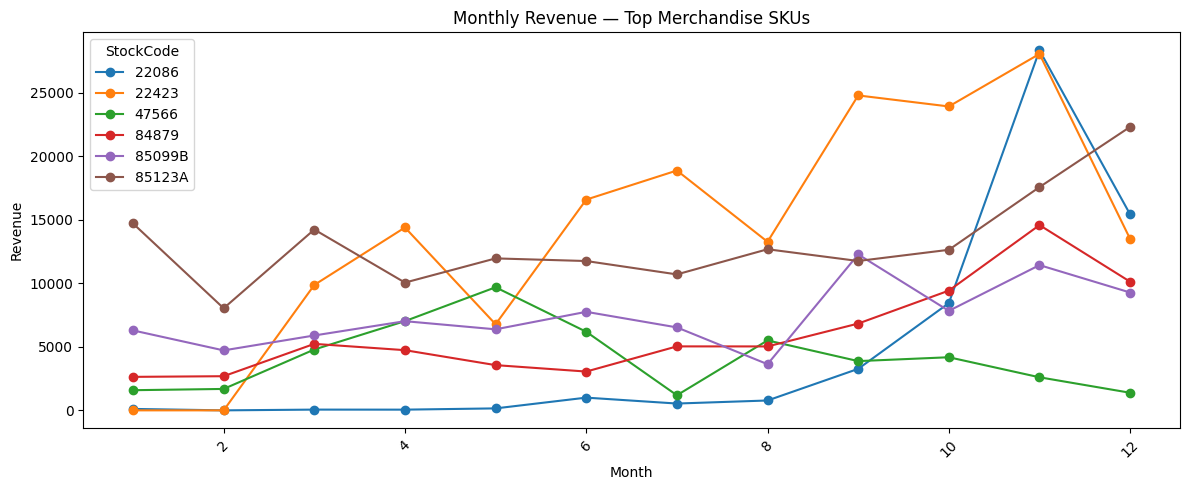

In [22]:
# Pick top 6 merchandise SKUs by revenue
top_n_merch = prod_rev_merch.head(6)['StockCode'].tolist()

# Filter only top merchandise SKUs for trends
prod_trends = (
    df_sales[df_sales['StockCode'].isin(top_n_merch) & ~df_sales['StockCode'].isin(operational_skus)]
    .groupby(['Month','StockCode'])['TotalPrice']
    .sum()
    .unstack()
    .fillna(0)
)

# Plot monthly revenue trends
prod_trends.plot(figsize=(12,5), marker='o')
plt.title('Monthly Revenue — Top Merchandise SKUs')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer-Level Analysis

In [23]:
import datetime as dt
# RFM segmentation
snapshot_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_sales.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days,),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).rename(columns={'InvoiceDate':'Recency','Invoice':'Frequency','TotalPrice':'Monetary'}).reset_index()

# Quartiles
rfm['R_quartile'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_quartile'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_quartile'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# RFM Score
rfm['RFM_Score'] = (rfm['R_quartile'].astype(int).astype(str) +
                    rfm['F_quartile'].astype(int).astype(str) +
                    rfm['M_quartile'].astype(int).astype(str))

# segments based on RFM rules
def assign_segment(row):
    if row['R_quartile'] == 5 and row['F_quartile'] == 5 and row['M_quartile'] == 5:
        return 'Champions'
    elif row['F_quartile'] >= 4 and row['M_quartile'] >= 4:
        return 'Loyal'
    elif row['R_quartile'] <= 2 and row['F_quartile'] >= 3:
        return 'At-risk'
    elif row['R_quartile'] <= 2 and row['F_quartile'] <= 2:
        return 'Lost'
    elif row['R_quartile'] >= 4 and row['F_quartile'] <= 2:
        return 'New'
    else:
        return 'Other'


rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Score,Segment
0,12346,165,11,372.86,2,5,2,252,At-risk
1,12347,3,2,1323.32,5,2,4,524,New
2,12348,74,1,222.16,2,1,1,211,Lost
3,12349,43,3,2671.14,3,3,5,335,Other
4,12351,11,1,300.93,5,1,2,512,New


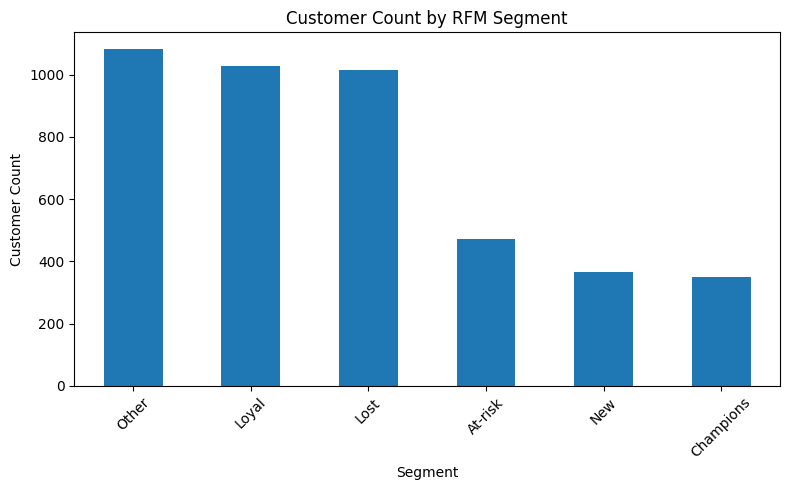

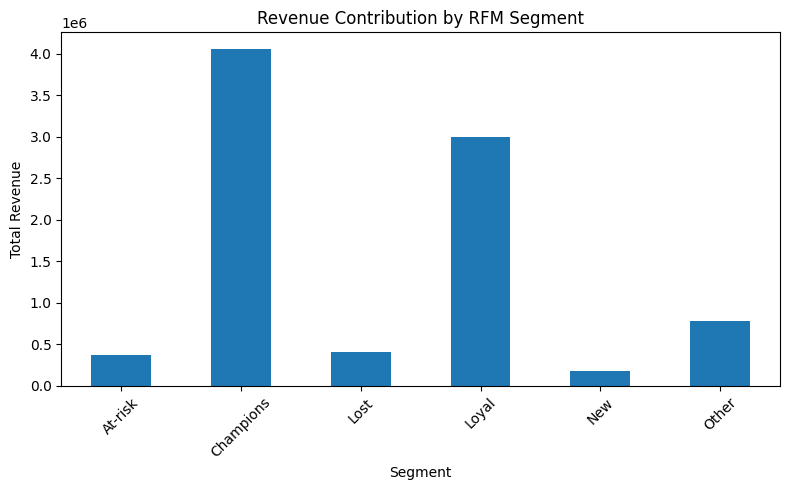

In [24]:
# --- Visualizations ---
# Customer Count by Segment
segment_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')
plt.title("Customer Count by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue Contribution by Segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()
plt.figure(figsize=(8,5))
segment_revenue.plot(kind='bar')
plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Top 100 customers
top100_customers = rfm.sort_values('Monetary', ascending=False).head(100)
top100_customers

,CustomerID,Recency,Frequency,Monetary,R_quartile,F_quartile,M_quartile,RFM_Score,Segment
4183,18102,1,89,349164.35,5,5,5,555,Champions
1637,14646,10,78,248396.50,5,5,5,555,Champions
1269,14156,7,102,196549.74,5,5,5,555,Champions
1840,14911,1,205,152121.22,5,5,5,555,Champions
939,13694,9,94,131443.19,5,5,5,555,Champions
...,...,...,...,...,...,...,...,...,...
170,12621,1,16,11086.14,5,5,5,555,Champions
3387,17044,10,11,11013.82,5,5,5,555,Champions
1556,14543,16,23,10988.14,4,5,5,455,Loyal
2343,15615,26,24,10974.23,4,5,5,455,Loyal


In [26]:
# Customers by country
country_cust = df_sales.groupby('Country').agg(
    revenue=('TotalPrice', 'sum'),
    customers=('CustomerID', 'nunique'),
    orders=('Invoice', 'nunique')
).sort_values('revenue', ascending=False).reset_index()

country_cust.head(20)

,Country,revenue,customers,orders
0,United Kingdom,8812311.833,3969,19290
1,EIRE,380909.570,5,348
2,Netherlands,268784.350,22,135
3,Germany,202025.391,67,347
4,France,147103.140,47,241
5,Sweden,53501.990,16,69
6,Denmark,50906.850,9,26
7,Spain,47568.650,25,66
8,Switzerland,43921.390,14,40
9,Australia,31446.800,15,40


In [27]:
# Pareto 80/20 check
cust_rev = df_sales.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
cum = cust_rev.cumsum() / cust_rev.sum()
cutoff_idx = int(len(cust_rev)*0.2)
pct_top20 = cust_rev.head(cutoff_idx).sum() / cust_rev.sum()
print(f"Top 20% customers contribute {pct_top20:.2%} of revenue")

Top 20% customers contribute 73.53% of revenue


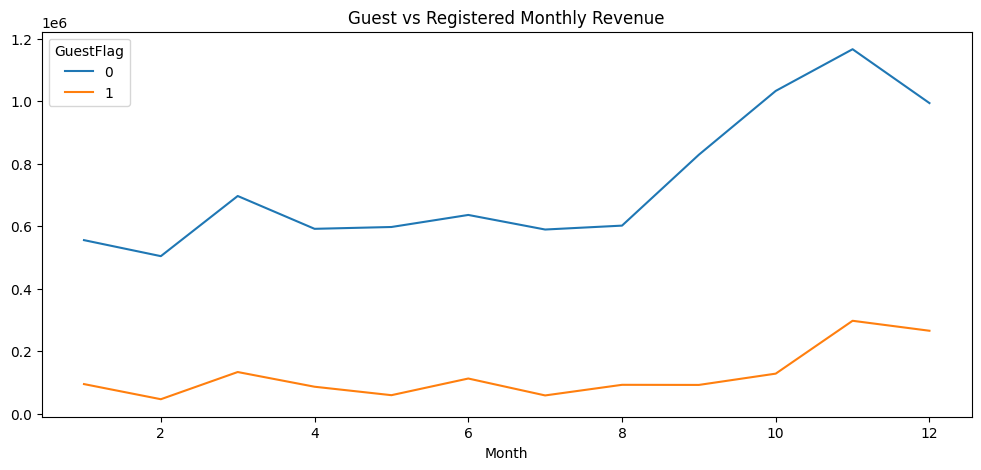

In [28]:
# Guest vs Registered deep dive
guest = df_sales.groupby('GuestFlag').agg(
    revenue=('TotalPrice','sum'),
    orders=('Invoice','nunique'),
    avg_order_value=('TotalPrice', lambda x: x.sum()/df_sales[df_sales['GuestFlag']==1]['Invoice'].nunique())
).reset_index()

# Monthly guest revenue trend
guest_monthly = df_sales.groupby(['Month','GuestFlag'])['TotalPrice'].sum().unstack(fill_value=0)
guest_monthly.plot(figsize=(12,5))
plt.title('Guest vs Registered Monthly Revenue')
plt.show()

 Simple Churn Analysis

In [29]:
last_date = df_sales['InvoiceDate'].max()
cutoff_active = last_date - pd.Timedelta(days=180)

# customers active in window 1 (180-360 days ago) but not in last 180 days -> churned
window1_start = last_date - pd.Timedelta(days=360)
window1_end = last_date - pd.Timedelta(days=181)

# Get customers active in Window 1
cust_w1 = df_sales[(df_sales['InvoiceDate']>=window1_start) & (df_sales['InvoiceDate']<=window1_end)]['CustomerID'].unique()

# Get customers active in recent 180 days
cust_recent = df_sales[df_sales['InvoiceDate']>cutoff_active]['CustomerID'].unique()

# Identify churned customers
churned_customers = set(cust_w1) - set(cust_recent)

# Calculate churn rate
churn_rate = len(churned_customers) / len(cust_w1)
churn_rate * 100

27.72950510011334

# Sales Pattern Analysis

In [30]:
# --- Small helper functions for line/bar plots ---
def plot_line(x, y, title, xlabel, ylabel, color='blue', alpha=1, linewidth=2, marker=None):
    plt.figure(figsize=(14,5))
    plt.plot(x, y, color=color, alpha=alpha, linewidth=linewidth, marker=marker)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_bar(x, y, title, xlabel, ylabel, color='steelblue'):
    plt.figure(figsize=(12,5))
    sns.barplot(x=x, y=y, color=color)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

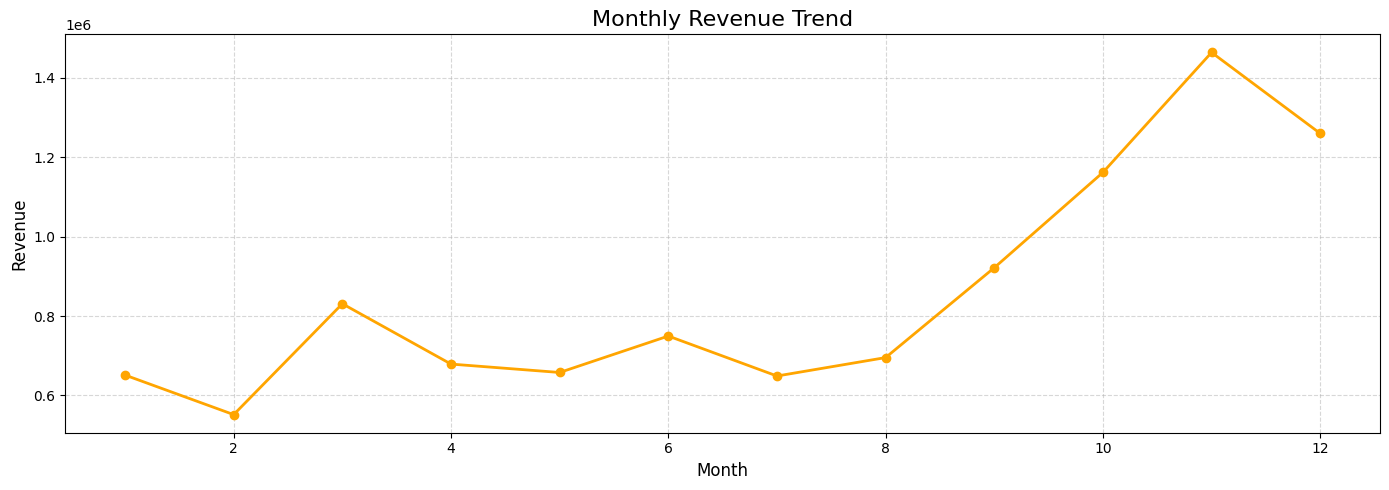

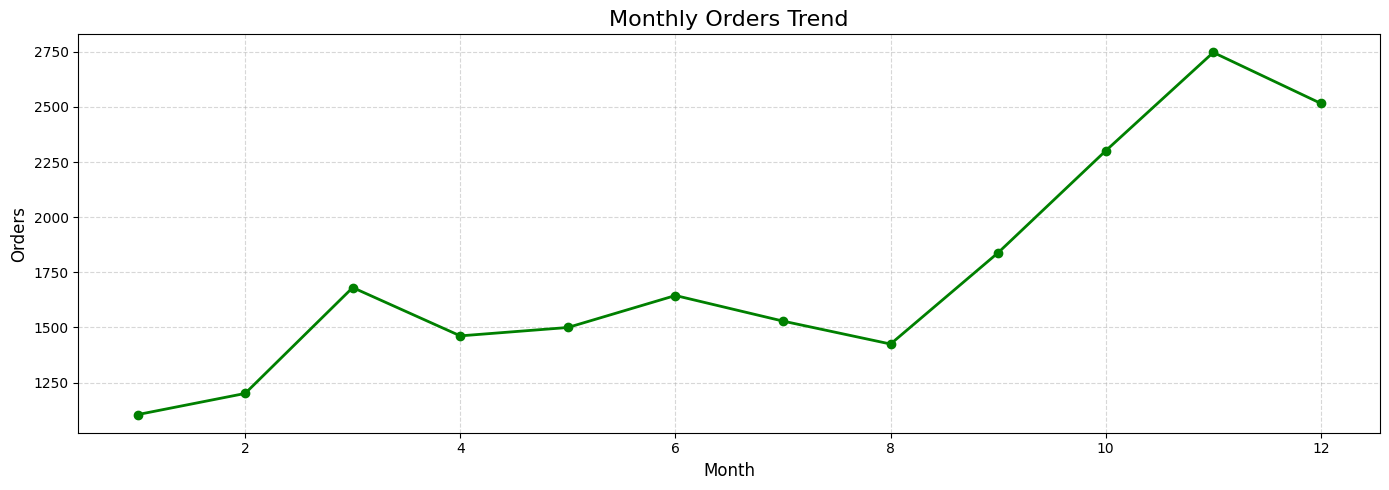

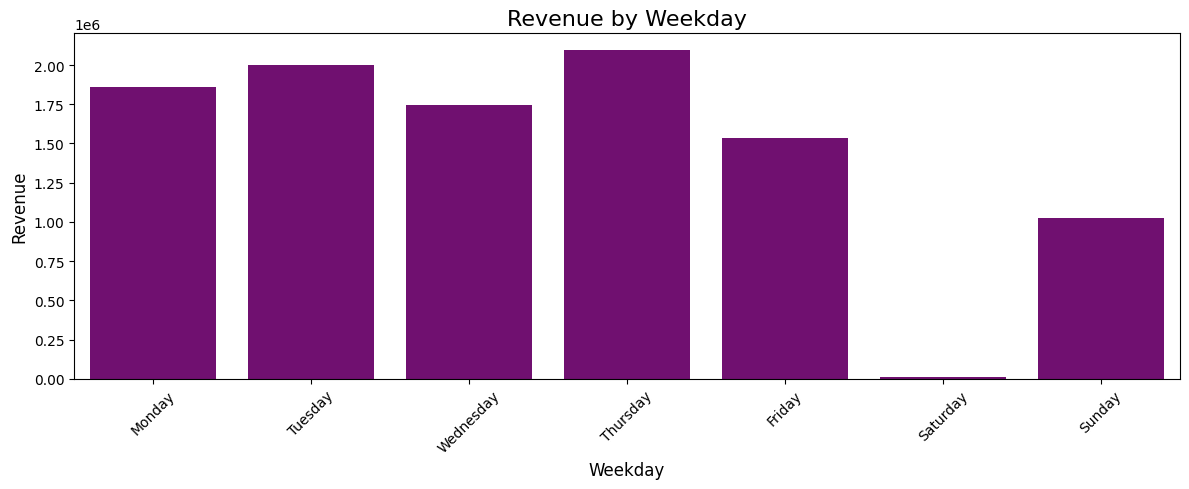

🔍 Weekend vs Weekday Revenue Ratio: 0.112


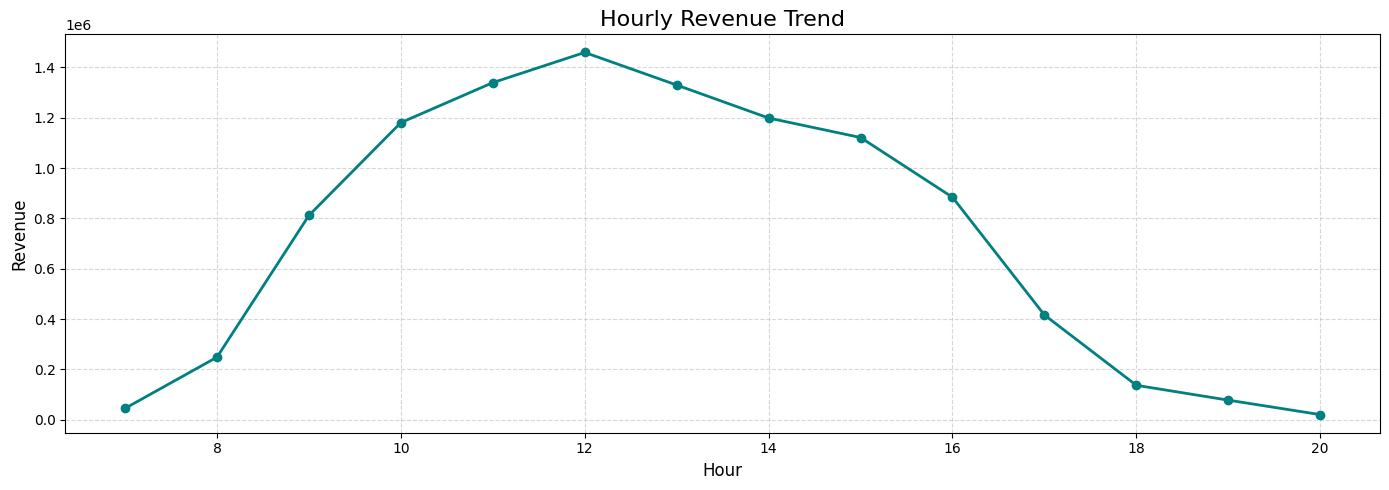

⏰ Peak Revenue Hour: 12:00 - 13:00


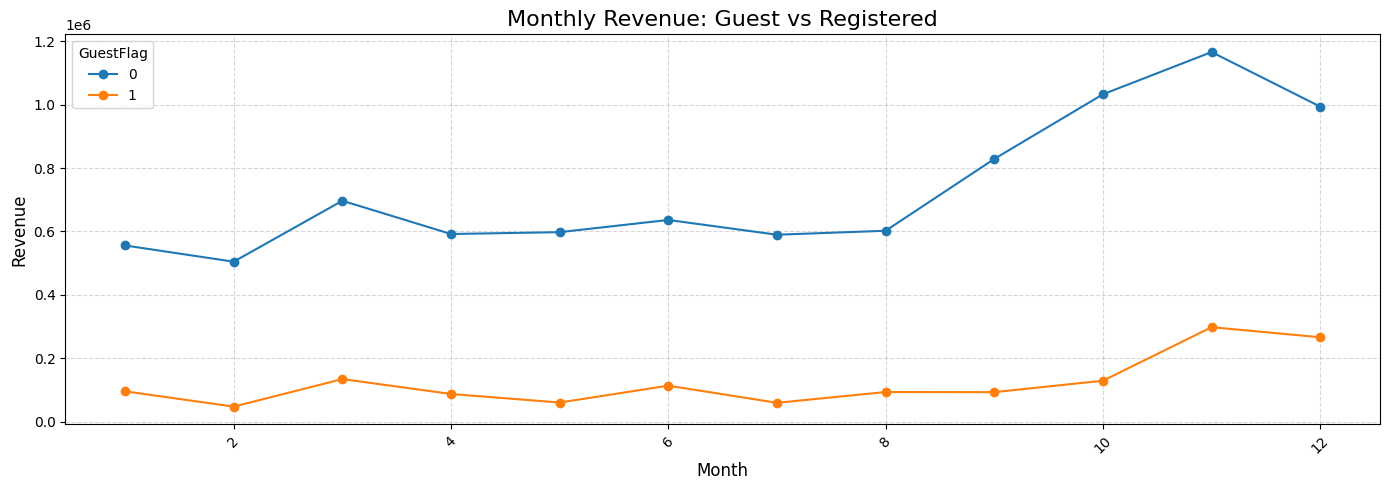


 STREAMLINED SALES TREND ANALYSIS COMPLETED.


In [31]:
def sales_trend_analysis_simple(df_sales, date_col='InvoiceDate', guest_col='GuestFlag'):

    # Monthly Revenue & Orders
    monthly = df_sales.groupby('Month').agg(
        Revenue=('TotalPrice','sum'),
        Orders=('Invoice','nunique')
    ).sort_index()
    plot_line(monthly.index, monthly['Revenue'], 'Monthly Revenue Trend', 'Month', 'Revenue', color='orange', marker='o')
    plot_line(monthly.index, monthly['Orders'], 'Monthly Orders Trend', 'Month', 'Orders', color='green', marker='o')

    # Weekday vs Weekend Revenue

    weekday_rev = df_sales.groupby('Weekday')['TotalPrice'].sum()
    weekday_rev = weekday_rev.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    plot_bar(weekday_rev.index, weekday_rev.values, 'Revenue by Weekday', 'Weekday', 'Revenue', color='purple')

    weekend = weekday_rev.loc[['Saturday','Sunday']].sum()
    weekdays_only = weekday_rev.loc[['Monday','Tuesday','Wednesday','Thursday','Friday']].sum()
    ratio = weekend / weekdays_only
    print(f"🔍 Weekend vs Weekday Revenue Ratio: {ratio:.3f}")

    # Hourly Revenue (Peak Hours)

    hourly_rev = df_sales.groupby('Hour')['TotalPrice'].sum()
    plot_line(hourly_rev.index, hourly_rev.values, 'Hourly Revenue Trend', 'Hour', 'Revenue', color='teal', marker='o')

    peak_hour = hourly_rev.idxmax()
    print(f"⏰ Peak Revenue Hour: {peak_hour}:00 - {peak_hour+1}:00")

    # Guest vs Registered Trend

    if guest_col in df_sales.columns:
        guest_month = df_sales.groupby(['Month', guest_col])['TotalPrice'].sum().unstack(fill_value=0).sort_index()
        guest_month.plot(kind='line', figsize=(14,5), marker='o')
        plt.title('Monthly Revenue: Guest vs Registered', fontsize=16)
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('Revenue', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    print("\n STREAMLINED SALES TREND ANALYSIS COMPLETED.")

sales_trend_analysis_simple(df_sales)

# DIAGNOSTIC ANALYSIS

# TREND DIAGNOSTICS
Goal: Understand why revenue and sales fluctuate over time.

Monthly Revenue Decomposition

In [32]:
# Step 1: Aggregate by month
monthly = df_sales.groupby('MonthName').agg(
    Revenue=('TotalPrice','sum'),
    Orders=('Invoice','nunique'),
    UnitsPerOrder=('Quantity', lambda x: x.sum()/x.nunique()),
    AvgPrice=('Price','mean')
).reset_index()

# Step 2: Log differences to capture percentage changes
monthly['dlog_Revenue'] = np.log(monthly['Revenue']).diff()
monthly['dlog_Orders'] = np.log(monthly['Orders']).diff()
monthly['dlog_AOV'] = np.log(monthly['Revenue']/monthly['Orders']).diff()

# Step 3: Convert to percentages
monthly['Revenue_Growth_%'] = monthly['dlog_Revenue'] * 100
monthly['Orders_Contribution_%'] = monthly['dlog_Orders'] / monthly['dlog_Revenue'] * 100
monthly['AOV_Contribution_%'] = monthly['dlog_AOV'] / monthly['dlog_Revenue'] * 100

monthly.tail(12)  # last 12 months


,MonthName,Revenue,Orders,UnitsPerOrder,AvgPrice,dlog_Revenue,dlog_Orders,dlog_AOV,Revenue_Growth_%,Orders_Contribution_%,AOV_Contribution_%
1,2010-01,651155.112,1105,2872.588235,4.654652,-0.233581,-0.420138,0.186557,-23.358109,179.868255,-79.868255
2,2010-02,551504.726,1201,3320.686957,3.775948,-0.166097,0.083309,-0.249407,-16.609747,-50.156819,150.156819
3,2010-03,830915.261,1681,3371.961538,5.156686,0.409877,0.336234,0.073643,40.987741,82.032897,17.967103
4,2010-04,678875.252,1462,3492.428571,4.365414,-0.202090,-0.139583,-0.062507,-20.209043,69.069819,30.930181
5,2010-05,657705.500,1500,3326.621849,3.895861,-0.031680,0.025660,-0.057340,-3.168012,-80.996356,180.996356
6,2010-06,749537.310,1645,3477.094017,4.808449,0.130699,0.092275,0.038424,13.069883,70.601454,29.398546
7,2010-07,648810.270,1529,2938.217391,3.925598,-0.144316,-0.073126,-0.071189,-14.431576,50.671150,49.328850
8,2010-08,695251.910,1425,2934.037267,3.919246,0.069134,-0.070442,0.139576,6.913391,-101.892277,201.892277
9,2010-09,921696.991,1839,3742.717949,4.345723,0.281942,0.255050,0.026892,28.194229,90.461823,9.538177
10,2010-10,1161902.220,2301,4366.169014,4.262590,0.231597,0.224122,0.007475,23.159726,96.772244,3.227756


In [33]:
# Sum of components
monthly['sum_components'] = monthly['dlog_Orders'] + monthly['dlog_AOV']

# Check
(monthly['dlog_Revenue'] - monthly['sum_components']).abs().max()

1.7763568394002505e-15

In [34]:
# Prepare table
decomp_table = monthly[['MonthName', 'Revenue_Growth_%', 'Orders_Contribution_%', 'AOV_Contribution_%']].copy()

# Round numbers for presentation
decomp_table['Revenue_Growth_%'] = decomp_table['Revenue_Growth_%'].round(2)
decomp_table['Orders_Contribution_%'] = decomp_table['Orders_Contribution_%'].round(2)
decomp_table['AOV_Contribution_%'] = decomp_table['AOV_Contribution_%'].round(2)

# Display table
print("📊 Monthly Revenue Decomposition")
print(decomp_table.to_string(index=False))

📊 Monthly Revenue Decomposition
MonthName  Revenue_Growth_%  Orders_Contribution_%  AOV_Contribution_%
  2009-12               NaN                    NaN                 NaN
  2010-01            -23.36                 179.87              -79.87
  2010-02            -16.61                 -50.16              150.16
  2010-03             40.99                  82.03               17.97
  2010-04            -20.21                  69.07               30.93
  2010-05             -3.17                 -81.00              181.00
  2010-06             13.07                  70.60               29.40
  2010-07            -14.43                  50.67               49.33
  2010-08              6.91                -101.89              201.89
  2010-09             28.19                  90.46                9.54
  2010-10             23.16                  96.77                3.23
  2010-11             23.13                  76.59               23.41
  2010-12           -120.78                  

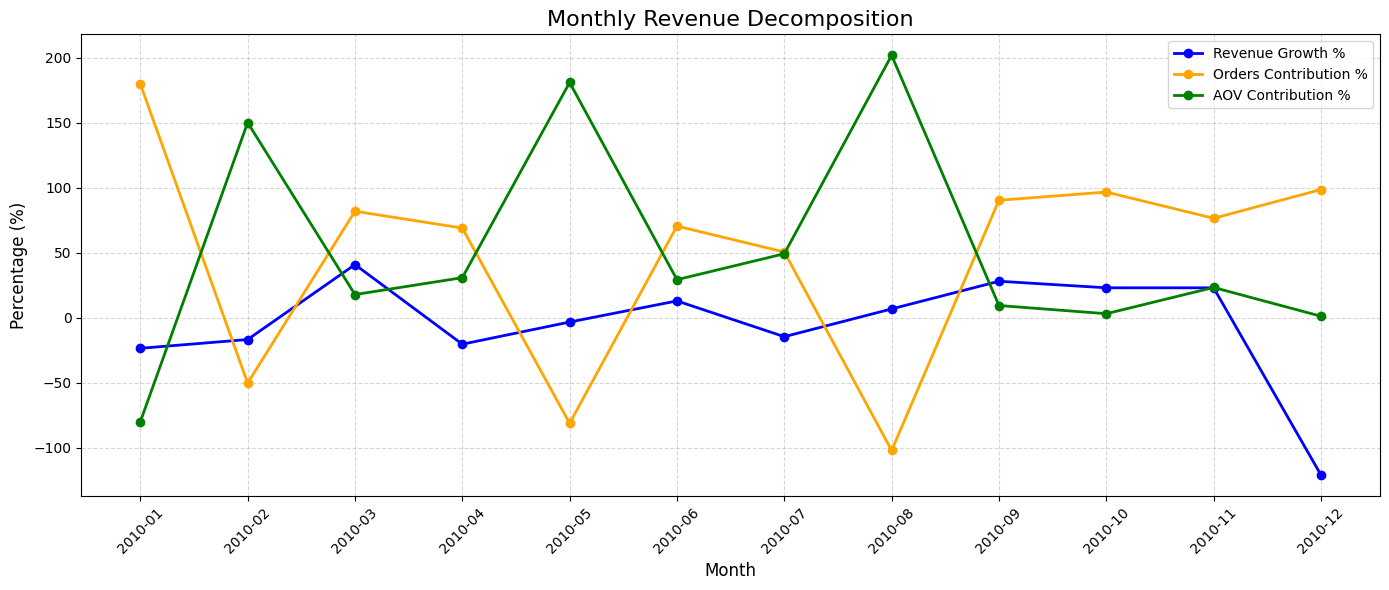

In [35]:
plt.figure(figsize=(14,6))

# Plot Revenue Growth %
plt.plot(monthly['MonthName'], monthly['Revenue_Growth_%'], marker='o', label='Revenue Growth %', color='blue', linewidth=2)

# Plot Orders Contribution %
plt.plot(monthly['MonthName'], monthly['Orders_Contribution_%'], marker='o', label='Orders Contribution %', color='orange', linewidth=2)

# Plot AOV Contribution %
plt.plot(monthly['MonthName'], monthly['AOV_Contribution_%'], marker='o', label='AOV Contribution %', color='green', linewidth=2)

plt.title("Monthly Revenue Decomposition", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion:**
Over the 12-month period, revenue exhibits moderate stability but is primarily driven by fluctuations in Average Order Value (AOV) rather than order volume, as indicated by consistently higher AOV contribution compared to Orders contribution. While customer activity remains relatively steady, months such as January, February, and August show pronounced AOV spikes, suggesting impacts from promotions, high-value purchases, or seasonal effects. Notably, December experienced a sharp revenue decline (-120.78%), signaling potential issues such as returns, cancellations, or operational anomalies that require investigation. To stabilize revenue, the business should focus on increasing consistent order volume through loyalty programs or recurring campaigns, while strategically managing high-value product promotions to maintain predictable growth.

In [36]:
# --- Step 1: Compute MoM % changes ---
monthly['Revenue_MoM_%'] = monthly['Revenue'].pct_change() * 100
monthly['Orders_MoM_%'] = monthly['Orders'].pct_change() * 100
monthly['AOV_MoM_%'] = (monthly['Revenue']/monthly['Orders']).pct_change() * 100

# --- Step 2: Prepare table ---
mom_table = monthly[['MonthName','Revenue_MoM_%','Orders_MoM_%','AOV_MoM_%']].copy()
mom_table = mom_table.round(2)

print("📊 Monthly MoM % Change")
print(mom_table.to_string(index=False))

📊 Monthly MoM % Change
MonthName  Revenue_MoM_%  Orders_MoM_%  AOV_MoM_%
  2009-12            NaN           NaN        NaN
  2010-01         -20.83        -34.30      20.51
  2010-02         -15.30          8.69     -22.07
  2010-03          50.66         39.97       7.64
  2010-04         -18.30        -13.03      -6.06
  2010-05          -3.12          2.60      -5.57
  2010-06          13.96          9.67       3.92
  2010-07         -13.44         -7.05      -6.87
  2010-08           7.16         -6.80      14.98
  2010-09          32.57         29.05       2.73
  2010-10          26.06         25.12       0.75
  2010-11          26.03         19.38       5.56
  2010-12         -70.11        -69.64      -1.56


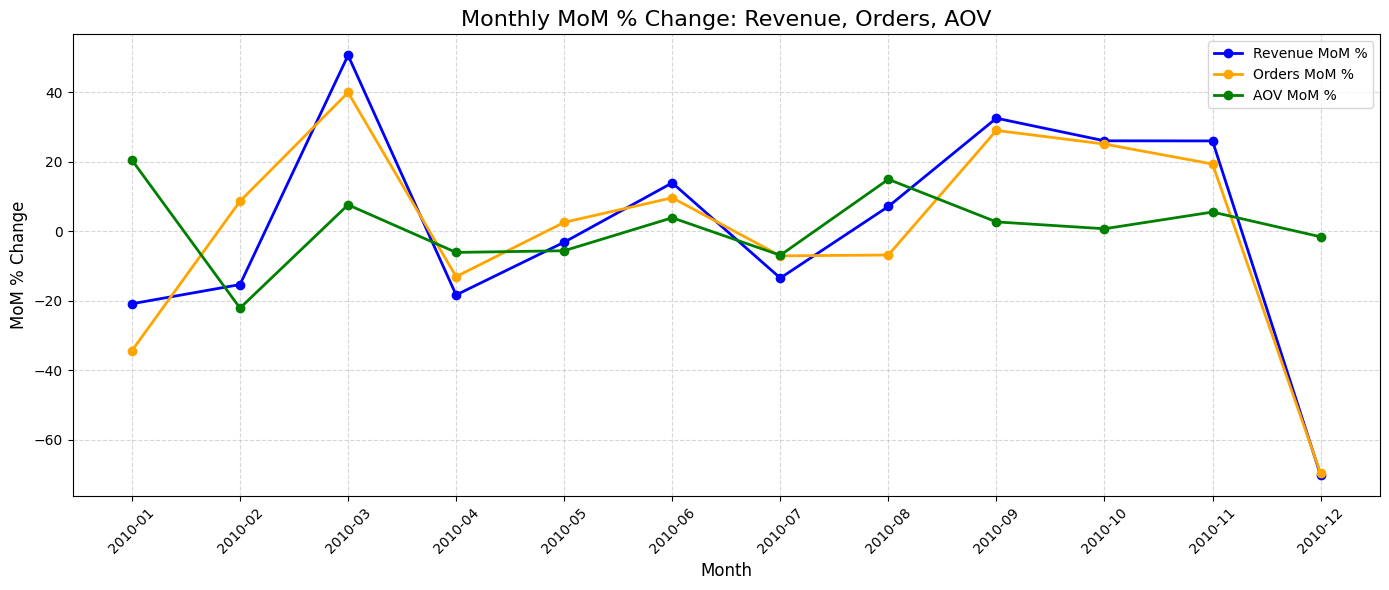

In [37]:
# --- Step 3: Line chart ---
plt.figure(figsize=(14,6))

plt.plot(monthly['MonthName'], monthly['Revenue_MoM_%'], marker='o', label='Revenue MoM %', color='blue', linewidth=2)
plt.plot(monthly['MonthName'], monthly['Orders_MoM_%'], marker='o', label='Orders MoM %', color='orange', linewidth=2)
plt.plot(monthly['MonthName'], monthly['AOV_MoM_%'], marker='o', label='AOV MoM %', color='green', linewidth=2)

plt.title("Monthly MoM % Change: Revenue, Orders, AOV", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("MoM % Change", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion for MOM % change:**
The revenue decomposition analysis highlights that AOV often appears as the dominant driver of revenue changes, showing high peaks in months where revenue fluctuates, whereas the Month-over-Month (MoM) % change for AOV remains relatively stable. This occurs because decomposition measures the relative contribution of each component to revenue change, so even small changes in AOV can appear magnified when order volume drops or revenue growth is low. In contrast, MoM % change reflects the actual month-to-month variation in AOV, which tends to be smoother since customer spending per order is more consistent. Insights for the business are clear: while revenue spikes and dips are primarily influenced by order volume, monitoring and strategically managing AOV remains important, especially during low-volume months, to stabilize overall revenue and maximize growth through targeted pricing or high-value product promotions.

Weekday & Hourly Diagnostics

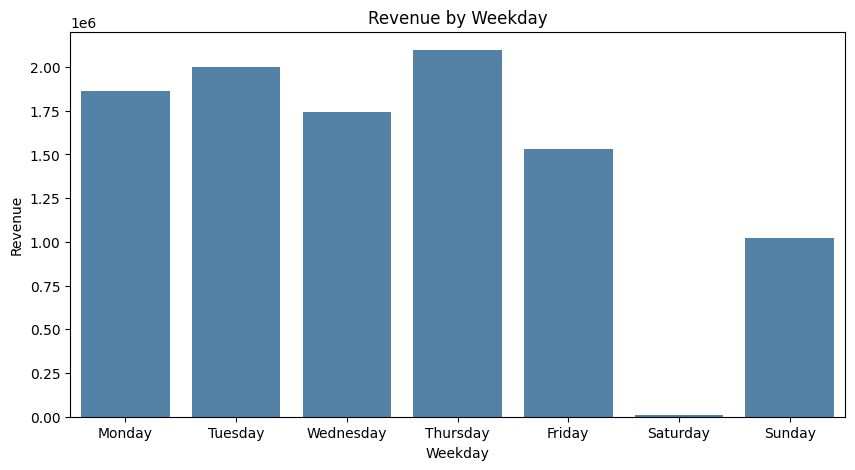

In [38]:
# Weekday trend
weekday_trend = df_sales.groupby('Weekday').agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('Invoice', 'nunique')
).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

weekday_trend['AOV'] = weekday_trend['Revenue'] / weekday_trend['Orders']

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=weekday_trend.index, y=weekday_trend['Revenue'], color='steelblue')
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.show()

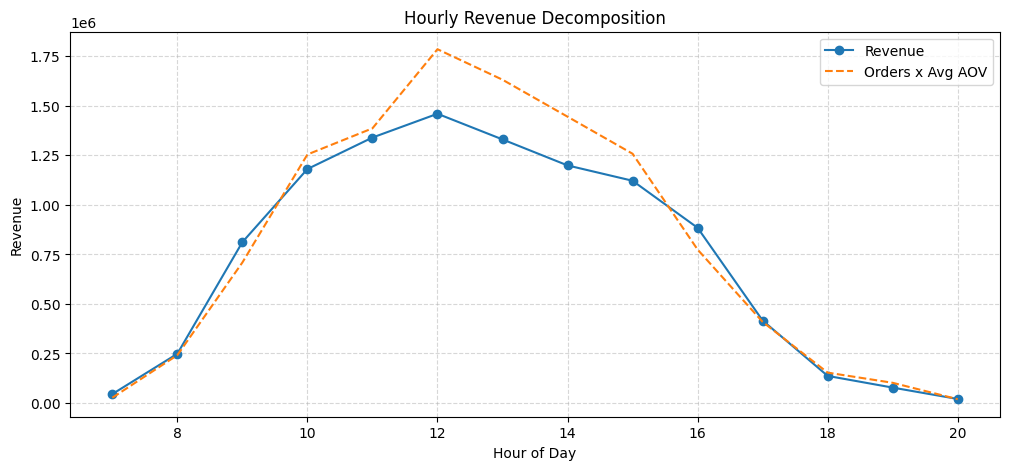

In [39]:
# Hourly Trend
hourly_trend = df_sales.groupby('Hour').agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('Invoice','nunique')
)

hourly_trend['AOV'] = hourly_trend['Revenue'] / hourly_trend['Orders']

# Plot

plt.figure(figsize=(12,5))
plt.plot(hourly_trend.index, hourly_trend['Revenue'], marker='o', label='Revenue')
plt.plot(hourly_trend.index, hourly_trend['Orders']*hourly_trend['AOV'].mean(), linestyle='--', label='Orders x Avg AOV')
plt.title('Hourly Revenue Decomposition')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Guest vs Registered Diagnostics

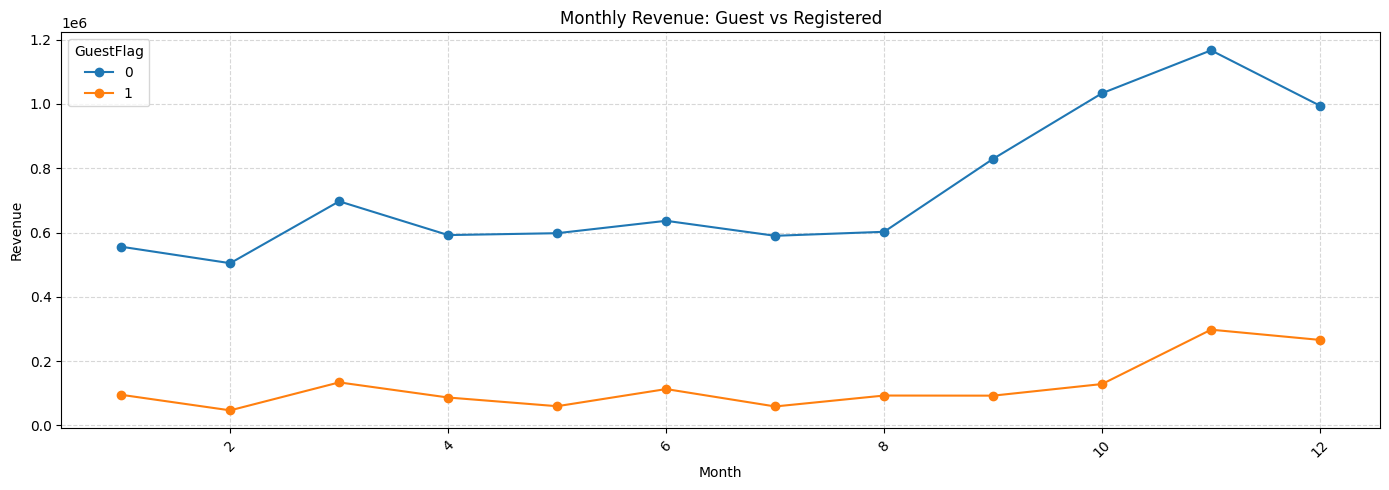

Guest vs Registered Revenue Contribution (%):
GuestFlag
0    85.654566
1    14.345434
dtype: float64


In [40]:
# Monthly revenue by GuestFlag
guest_monthly = df_sales.groupby(['Month','GuestFlag'])['TotalPrice'].sum().unstack(fill_value=0)

# Plot
guest_monthly.plot(kind='line', figsize=(14,5), marker='o')
plt.title('Monthly Revenue: Guest vs Registered')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Calculate contribution %
guest_pct = guest_monthly.sum()/guest_monthly.sum().sum()*100
print("Guest vs Registered Revenue Contribution (%):")
print(guest_pct)

# Product Diagnostics

Goal:
To explains why certain products succeed and why others fail (returns).

Price Return Relationship

In [41]:
# Non-merchandise / adjustment codes
NON_PRODUCTS = ['ADJUST', 'AMAZONFEE', 'BANK CHARGES', 'D', 'S', 'M', 'gift_0001_80']

In [42]:
# Purpose: Identify products with consistently high and low return behavior after ensuring
# sufficient sales volume.

# Sort products by return rate (descending = high returns)
ret_sorted = ret_rate_filtered.sort_values('ReturnRate_qty', ascending=False)

# Top & bottom 50 products by return rate
high_ret_products = ret_sorted.head(50)['StockCode']
low_ret_products  = ret_sorted.tail(50)['StockCode']

In [43]:
# Purpose: Compare average prices of high-return vs low-return
# products using actual selling prices, not returns.

# Compute average selling price using VALID SALES ONLY
avg_price_sales = (
    df_sales
    .groupby('StockCode')['Price']
    .mean()
)

# Extract prices for high- and low-return products
high_ret_prices = avg_price_sales.loc[
    avg_price_sales.index.intersection(high_ret_products)
]

low_ret_prices = avg_price_sales.loc[
    avg_price_sales.index.intersection(low_ret_products)
]

In [44]:
# Remove non-product / adjustment codes
high_ret_prices_clean = high_ret_prices[~high_ret_prices.index.isin(NON_PRODUCTS)]
low_ret_prices_clean  = low_ret_prices[~low_ret_prices.index.isin(NON_PRODUCTS)]

print("High-return products — average price:", round(high_ret_prices_clean.mean(), 2))
print("Low-return products  — average price:", round(low_ret_prices_clean.mean(), 2))

# Client Interpretation:
# After excluding non-merchandise SKUs, high-return products are only slightly cheaper than low-return
# products. The price difference is marginal, indicating that price alone does not strongly drive return behavior.

High-return products — average price: 4.02
Low-return products  — average price: 4.05


In [45]:
# Purpose: Test whether price explains return behavior across all products.

# Merge filtered return rates with average selling prices
price_return = (
    ret_rate_filtered[['StockCode', 'ReturnRate_qty']]
    .merge(
        avg_price_sales.reset_index().rename(columns={'Price':'AvgPrice'}),
        on='StockCode',
        how='inner'
    )
)

# Remove non-products
price_return_clean = price_return[~price_return['StockCode'].isin(NON_PRODUCTS)]

# Correlation
corr_price_return = price_return_clean['AvgPrice'].corr(
    price_return_clean['ReturnRate_qty']
)

print("Correlation between average price and return rate:", round(corr_price_return, 3))

# Client Interpretation:
# There is no strong linear relationship between product price and return rates.
# This suggests that pricing, by itself, does not explain why products are returned.

Correlation between average price and return rate: 0.072


In [46]:
# Purpose: Determine whether pricing inconsistency (discounting, changes) drives returns.

# Compute average price and price volatility (sales only)
price_stats = (
    df_sales
    .groupby('StockCode')['Price']
    .agg(AvgPrice='mean', PriceStd='std')
    .reset_index()
)

# Merge with filtered return rates
price_return = (
    ret_rate_filtered[['StockCode', 'ReturnRate_qty']]
    .merge(price_stats, on='StockCode', how='inner')
)

# Remove non-products
price_return_clean = price_return[~price_return['StockCode'].isin(NON_PRODUCTS)]

# Cap extreme outliers for visualization clarity
cap_std    = price_return_clean['PriceStd'].quantile(0.95)
cap_return = price_return_clean['ReturnRate_qty'].quantile(0.95)

price_return_viz = price_return_clean[
    (price_return_clean['PriceStd'] <= cap_std) &
    (price_return_clean['ReturnRate_qty'] <= cap_return)
]

# Correlation
corr_volatility = price_return_viz['PriceStd'].corr(
    price_return_viz['ReturnRate_qty']
)

print("Correlation between price volatility and return rate:", round(corr_volatility, 3))

Correlation between price volatility and return rate: 0.12


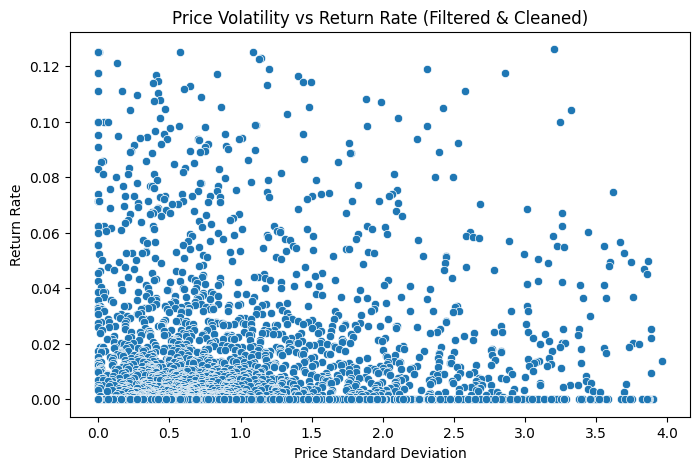

In [47]:
# Visualization

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=price_return_viz,
    x='PriceStd',
    y='ReturnRate_qty'
)
plt.title('Price Volatility vs Return Rate (Filtered & Cleaned)')
plt.xlabel('Price Standard Deviation')
plt.ylabel('Return Rate')
plt.show()

# Client Interpretation
# Most products exhibit very low price volatility, reflecting a stable pricing structure.
# There is no meaningful relationship between price variability and return rates,
# indicating that returns are unlikely to be driven by pricing mechanics such as discounting.

In [48]:
# Purpose: Convert diagnostics into actionable business categories.
# Thresholds (quantile-based, data-driven)
high_return_threshold = price_return_clean['ReturnRate_qty'].quantile(0.8)
cheap_price_threshold = price_return_clean['AvgPrice'].quantile(0.2)
expensive_price_threshold = price_return_clean['AvgPrice'].quantile(0.8)

def classify_product(row):
    if row['ReturnRate_qty'] >= high_return_threshold and row['AvgPrice'] <= cheap_price_threshold:
        return 'Cheap High-Return (Impulse)'
    elif row['ReturnRate_qty'] >= high_return_threshold and row['AvgPrice'] >= expensive_price_threshold:
        return 'Expensive High-Return (Risk)'
    else:
        return 'Other'

price_return_clean['Category'] = price_return_clean.apply(classify_product, axis=1)

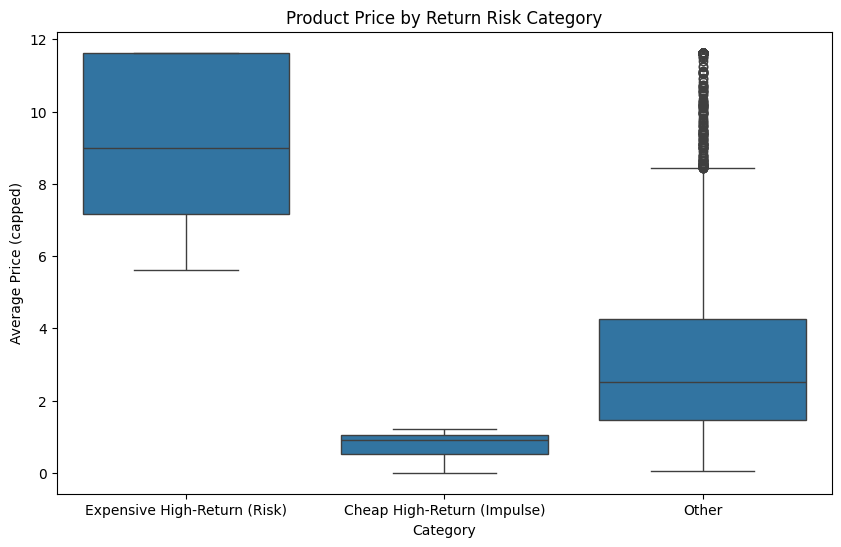

In [49]:
# Visualization

# Cap extreme prices for clean visualization
cap_price = price_return_clean['AvgPrice'].quantile(0.95)
price_return_clean['AvgPrice_capped'] = np.minimum(
    price_return_clean['AvgPrice'], cap_price
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=price_return_clean,
    x='Category',
    y='AvgPrice_capped'
)
plt.title('Product Price by Return Risk Category')
plt.ylabel('Average Price (capped)')
plt.xlabel('Category')
plt.show()

Conclusion: After controlling for sales volume and excluding non-merchandise items, we find that product price and price volatility do not meaningfully explain return behavior. Returns appear to be driven more by operational factors such as product fit, fulfillment, or customer expectations rather than pricing strategy. This allows the business to focus return-reduction efforts on targeted product categories rather than broad pricing changes.

Bulk vs Single-selling Analysis:
Are product returns driven by bulk purchasing behavior or by single-unit consumer purchases?

In [50]:
df['AbsQuantity'] = df['Quantity'].abs()

df['SellingMode'] = np.where(
    df['AbsQuantity'] >= 10, 'Bulk',
    np.where(df['AbsQuantity'] == 1, 'Single', 'Other')
)

df_mode = df[df['SellingMode'].isin(['Bulk', 'Single'])].copy()

In [51]:
# Sold units (positive quantities only)
sold_units = (
    df_mode[df_mode['ValidSaleFlag'] == 1]
    .groupby('SellingMode')['Quantity']
    .sum()
)

# Returned units (absolute)
returned_units = (
    df_mode[df_mode['ReturnFlag'] == 1]
    .groupby('SellingMode')['Quantity']
    .apply(lambda x: x.abs().sum())
)

bulk_single_summary = pd.concat(
    [sold_units, returned_units],
    axis=1
).fillna(0)

bulk_single_summary.columns = ['SoldUnits', 'ReturnedUnits']

bulk_single_summary['ReturnRate'] = (
    bulk_single_summary['ReturnedUnits'] /
    bulk_single_summary['SoldUnits']
)

bulk_single_summary

,SoldUnits,ReturnedUnits,ReturnRate
SellingMode,,,
Bulk,4823736,194822,0.040388
Single,140795,4568,0.032444


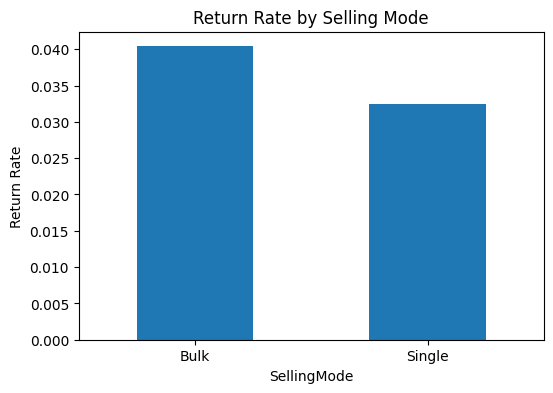

In [52]:
bulk_single_summary['ReturnRate'].plot(
    kind='bar',
    figsize=(6,4)
)
plt.title('Return Rate by Selling Mode')
plt.ylabel('Return Rate')
plt.xticks(rotation=0)
plt.show()

Conclusion: Bulk purchases account for the vast majority of sales volume and returned units. While bulk orders are returned slightly more often than single-unit purchases, the difference in return rate is modest. However, due to the scale of bulk transactions, even small increases in bulk return rates have a disproportionately large operational impact.

Return Value Impact

In [53]:
# Sold Value
sold_value = (
    df_mode[df_mode['ValidSaleFlag'] == 1]
    .groupby('SellingMode')['TotalPrice']
    .sum()
)

# Returned Value
returned_value = (
    df_mode[df_mode['ReturnFlag'] == 1]
    .groupby('SellingMode')['TotalPrice']
    .apply(lambda x: x.abs().sum())  # ensure returns are positive
)


# Combine into summary
bulk_single_value = pd.concat([sold_value, returned_value], axis=1).fillna(0)
bulk_single_value.columns = ['SoldValue', 'ReturnedValue']

# Safe return rate (avoid division by zero)
bulk_single_value['ReturnRateValue'] = np.where(
    bulk_single_value['SoldValue'] != 0,
    (bulk_single_value['ReturnedValue'] / bulk_single_value['SoldValue']) * 100,
    0
)

bulk_single_value

,SoldValue,ReturnedValue,ReturnRateValue
SellingMode,,,
Bulk,6301289.330,167357.94,2.655932
Single,1114602.564,404156.13,36.260111


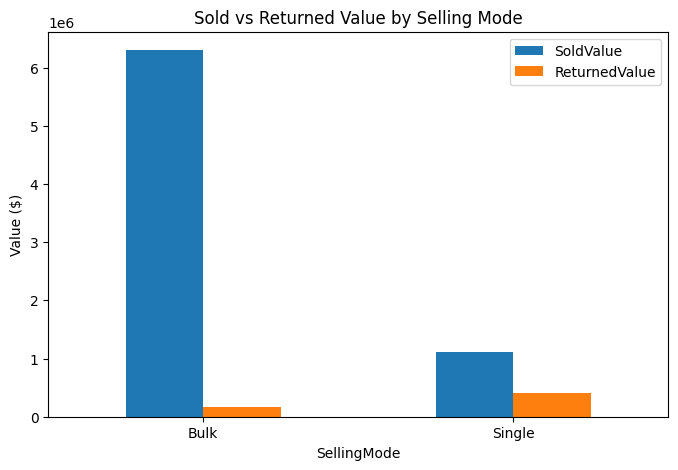

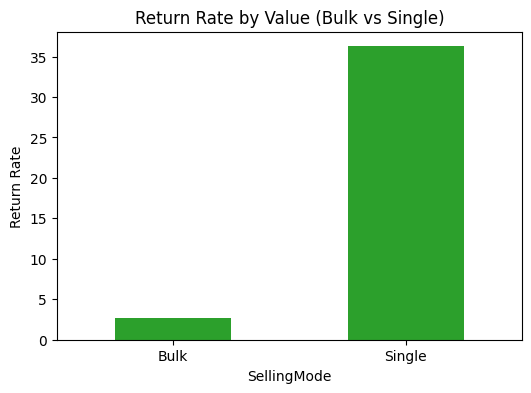

In [54]:
# Visualization

# Sold Vs Returned Value
bulk_single_value[['SoldValue', 'ReturnedValue']].plot(
    kind='bar',
    figsize=(8,5),
    color=['#1f77b4', '#ff7f0e']
)
plt.title('Sold vs Returned Value by Selling Mode')
plt.ylabel('Value ($)')
plt.xticks(rotation=0)
plt.show()

# Return Rate by Value
bulk_single_value['ReturnRateValue'].plot(
    kind='bar',
    figsize=(6,4),
    color='#2ca02c'
)
plt.title('Return Rate by Value (Bulk vs Single)')
plt.ylabel('Return Rate')
plt.xticks(rotation=0)
plt.show()

# Predictive Analysis


# Customer-Level Predictive Analysis
Churn Prediction

In [55]:
# ============================================================
# PREDICTIVE ANALYSIS — CHURN FEATURE ENGINEERING (CLEAN)
# ============================================================

# ── 1. Time windows ──────────────────────────────────────────
obs_start   = pd.Timestamp("2009-12-01")
obs_end     = pd.Timestamp("2010-06-30")
churn_start = pd.Timestamp("2010-07-01")
churn_end   = pd.Timestamp("2010-09-30")

df_obs_sales = df_sales[
    (df_sales['InvoiceDate'] >= obs_start) &
    (df_sales['InvoiceDate'] <= obs_end) &
    df_sales['CustomerID'].notna()
].copy()

df_obs_all = df[
    (df['InvoiceDate'] >= obs_start) &
    (df['InvoiceDate'] <= obs_end) &
    df['CustomerID'].notna()
].copy()

df_churn_window = df_sales[
    (df_sales['InvoiceDate'] >= churn_start) &
    (df_sales['InvoiceDate'] <= churn_end) &
    df_sales['CustomerID'].notna()
].copy()

print(f"Obs window (sales) rows : {len(df_obs_sales):,}")
print(f"Obs window (all) rows   : {len(df_obs_all):,}")
print(f"Churn window rows       : {len(df_churn_window):,}")
print(f"Unique customers in obs : {df_obs_sales['CustomerID'].nunique():,}")

# ── 2. Snapshot & mid-point ──────────────────────────────────
snapshot  = obs_end + pd.Timedelta(days=1)
mid_point = obs_start + (obs_end - obs_start) / 2

# ── 3. Early / late spend — SALES ONLY ───────────────────────
early_spend = (
    df_obs_sales[df_obs_sales['InvoiceDate'] <= mid_point]
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .rename('early_spend')
)

late_spend = (
    df_obs_sales[df_obs_sales['InvoiceDate'] > mid_point]
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .rename('late_spend')
)

# ── 4. Return behavior — full transaction history ─────────────
return_counts = (
    df_obs_all[df_obs_all['ReturnFlag'] == 1]
    .groupby('CustomerID')['Invoice']
    .nunique()
    .rename('return_count')
)

# ── 5. Engagement features ────────────────────────────────────
df_obs_sales['YearMonth'] = df_obs_sales['InvoiceDate'].dt.to_period('M')

months_active = (
    df_obs_sales.groupby('CustomerID')['YearMonth']
    .nunique()
    .rename('months_active')
)

last_30_cutoff = obs_end - pd.Timedelta(days=30)
last_60_cutoff = obs_end - pd.Timedelta(days=60)

active_last_30 = (
    df_obs_sales[df_obs_sales['InvoiceDate'] >= last_30_cutoff]
    .groupby('CustomerID')['Invoice']
    .nunique().gt(0).astype(int)
    .rename('active_last_30')
)

active_last_60 = (
    df_obs_sales[df_obs_sales['InvoiceDate'] >= last_60_cutoff]
    .groupby('CustomerID')['Invoice']
    .nunique().gt(0).astype(int)
    .rename('active_last_60')
)

# ── 6. Core RFM aggregation — SALES ONLY ─────────────────────
features = (
    df_obs_sales
    .groupby('CustomerID')
    .agg(
        recency           = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
        frequency         = ('Invoice', 'nunique'),
        monetary          = ('TotalPrice', 'sum'),
        unique_products   = ('StockCode', 'nunique'),
        avg_quantity      = ('Quantity', 'mean'),
        customer_lifespan = ('InvoiceDate', lambda x: (x.max() - x.min()).days + 1),
        country           = ('Country', lambda x: x.mode()[0])
    )
    .reset_index()
)

features['avg_order_value'] = features['monetary'] / features['frequency']
features['avg_days_between_orders'] = (
    features['customer_lifespan'] / features['frequency']
).replace([np.inf, np.nan], 0)

# ── 7. Merge all derived features ────────────────────────────
features = (
    features
    .merge(early_spend,    on='CustomerID', how='left')
    .merge(late_spend,     on='CustomerID', how='left')
    .merge(return_counts,  on='CustomerID', how='left')
    .merge(months_active,  on='CustomerID', how='left')
    .merge(active_last_30, on='CustomerID', how='left')
    .merge(active_last_60, on='CustomerID', how='left')
)

fill_cols = ['early_spend', 'late_spend', 'return_count',
             'months_active', 'active_last_30', 'active_last_60']
features[fill_cols] = features[fill_cols].fillna(0)

# ── 8. Spend trend — capped at 10x to suppress outliers ──────
# Only computed when early_spend > 0 (negative/zero means
# returns dominated that half, ratio is meaningless)

# Flag new arrivals first
features['new_in_late_window'] = (features['early_spend'] == 0).astype(int)

# Compute raw spend trend only where early_spend > 0
raw_trend = (features['late_spend'] / features['early_spend'].replace(0, np.nan)).clip(upper=10.0)

# Get median from valid rows only (before assigning anything)
median_trend = raw_trend[features['early_spend'] > 0].median()

# Now assign spend_trend — new arrivals get median, everyone else gets their real ratio
features['spend_trend'] = np.where(
    features['early_spend'] > 0,
    raw_trend,
    median_trend
)

# ── 9. Return rate — capped at 1.0 ───────────────────────────
# Returns > frequency occur when customer returned obs-window
# purchases made BEFORE the window opened → cap, don't drop
features['return_rate'] = (
    features['return_count'] / features['frequency']
).clip(upper=1.0)

# ── 10. Churn label ───────────────────────────────────────────
active_in_churn = set(df_churn_window['CustomerID'].dropna().unique())
features['Churned'] = features['CustomerID'].apply(
    lambda x: 0 if x in active_in_churn else 1
)

# ── 11. Filter low-history customers ─────────────────────────
features = features[features['frequency'] >= 2].copy()

# ── 12. Encode country — OHE for model compatibility ─────────
top_countries = features['country'].value_counts().head(10).index
features['country'] = features['country'].where(
    features['country'].isin(top_countries), 'Other'
)
features = pd.get_dummies(features, columns=['country'], drop_first=False)

# ── 13. Sanity checks ─────────────────────────────────────────
print("\n=== CHURN DATAFRAME SUMMARY ===")
print(f"Total customers  : {len(features):,}")
print(f"Churned (1)      : {features['Churned'].sum():,} ({features['Churned'].mean():.1%})")
print(f"Retained (0)     : {(features['Churned']==0).sum():,} ({(features['Churned']==0).mean():.1%})")
print(f"Feature columns  : {len(features.columns) - 2}")
print(f"Nulls            : {features.isnull().sum().sum()}")  # should be 0

print(f"\nSpend trend  — min: {features['spend_trend'].min():.2f}, max: {features['spend_trend'].max():.2f}")
print(f"Return rate  — min: {features['return_rate'].min():.2f}, max: {features['return_rate'].max():.2f}")

# Confirm OHE worked
country_cols = [c for c in features.columns if c.startswith('country_')]
print(f"\nCountry OHE columns ({len(country_cols)}): {country_cols}")

# ── 14. Save ──────────────────────────────────────────────────
features.to_parquet("churn_features.parquet", index=False)
print("\n✅ Churn features saved.")

Obs window (sales) rows : 190,848
Obs window (all) rows   : 196,067
Churn window rows       : 85,060
Unique customers in obs : 2,961

=== CHURN DATAFRAME SUMMARY ===
Total customers  : 1,692
Churned (1)      : 608 (35.9%)
Retained (0)     : 1,084 (64.1%)
Feature columns  : 28
Nulls            : 0

Spend trend  — min: 0.00, max: 10.00
Return rate  — min: 0.00, max: 1.00

Country OHE columns (11): ['country_Belgium', 'country_Cyprus', 'country_France', 'country_Germany', 'country_Italy', 'country_Netherlands', 'country_Other', 'country_Portugal', 'country_Spain', 'country_Switzerland', 'country_United Kingdom']

✅ Churn features saved.


In [56]:
features.head(20)

,CustomerID,recency,frequency,monetary,unique_products,avg_quantity,customer_lifespan,avg_order_value,avg_days_between_orders,early_spend,...,country_Cyprus,country_France,country_Germany,country_Italy,country_Netherlands,country_Other,country_Portugal,country_Spain,country_Switzerland,country_United Kingdom
0,12346,2,11,372.86,26,2.121212,197,33.896364,17.909091,230.55,...,False,False,False,False,False,False,False,False,False,True
1,12349,43,2,1268.52,47,10.085106,19,634.260000,9.500000,0.00,...,False,False,False,True,False,False,False,False,False,False
3,12358,23,2,1697.93,34,16.857143,182,848.965000,91.000000,1429.83,...,False,False,False,False,False,True,False,False,False,False
4,12359,8,5,2012.03,82,10.197674,199,402.406000,39.800000,1176.63,...,True,False,False,False,False,False,False,False,False,False
5,12360,36,3,780.04,44,16.800000,93,260.013333,31.000000,118.00,...,False,False,False,False,False,True,False,False,False,False
6,12361,52,2,207.35,11,6.384615,104,103.675000,52.000000,109.20,...,False,False,False,False,False,False,False,False,False,False
11,12370,97,3,774.62,33,7.200000,45,258.206667,15.000000,562.96,...,False,False,False,False,False,True,False,False,False,False
12,12371,118,2,607.68,32,7.411765,1,303.840000,0.500000,607.68,...,False,False,False,False,False,False,False,False,True,False
13,12373,97,2,763.05,31,8.621622,50,381.525000,25.000000,437.90,...,False,False,False,False,False,True,False,False,False,False
18,12380,1,6,5814.65,98,12.671875,135,969.108333,22.500000,3217.30,...,False,False,False,False,False,False,False,False,False,False


In [57]:
features.columns

Index(['CustomerID', 'recency', 'frequency', 'monetary', 'unique_products',
       'avg_quantity', 'customer_lifespan', 'avg_order_value',
       'avg_days_between_orders', 'early_spend', 'late_spend', 'return_count',
       'months_active', 'active_last_30', 'active_last_60',
       'new_in_late_window', 'spend_trend', 'return_rate', 'Churned',
       'country_Belgium', 'country_Cyprus', 'country_France',
       'country_Germany', 'country_Italy', 'country_Netherlands',
       'country_Other', 'country_Portugal', 'country_Spain',
       'country_Switzerland', 'country_United Kingdom'],
      dtype='object')

In [58]:
# Load parquet
df_churn = pd.read_parquet("churn_features.parquet")

# Convert to CSV
df_churn.to_csv("churn_features.csv", index=False)

# Download
from google.colab import files
files.download("churn_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Ensure proper datetime format
monthly['Month'] = pd.to_datetime(monthly['MonthName'])

# Sort chronologically
monthly = monthly.sort_values('Month')

# Keep only what we need (clean & minimal)
rev_forecast_df = monthly[['Month', 'Revenue']].copy()

rev_forecast_df.head()

,Month,Revenue
0,2009-12-01,822483.950
1,2010-01-01,651155.112
2,2010-02-01,551504.726
3,2010-03-01,830915.261
4,2010-04-01,678875.252


In [60]:
rev_forecast_df.to_csv("monthly_revenue_forecast.csv", index=False)
from google.colab import files
files.download("monthly_revenue_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
from google.colab import files
files.download("df_sales.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

w

In [64]:
import os
for f in sorted(os.listdir("report_figures")):
  print(f)

customer_count_by_rfm_segment.png
guest_vs_registered_monthly_revenue.png
hourly_revenue_decomposition.png
hourly_revenue_trend.png
monthly_mom_change_revenue_orders_aov.png
monthly_orders_trend.png
monthly_revenue_decomposition.png
monthly_revenue_guest_vs_registered.png
monthly_revenue_guest_vs_registered_2.png
monthly_revenue_top_merchandise_skus.png
monthly_revenue_trend.png
price_volatility_vs_return_rate_filtered_cleaned.png
product_price_by_return_risk_category.png
return_rate_by_selling_mode.png
return_rate_by_value_bulk_vs_single.png
revenue_by_weekday.png
revenue_by_weekday_2.png
revenue_contribution_by_rfm_segment.png
sold_vs_returned_value_by_selling_mode.png


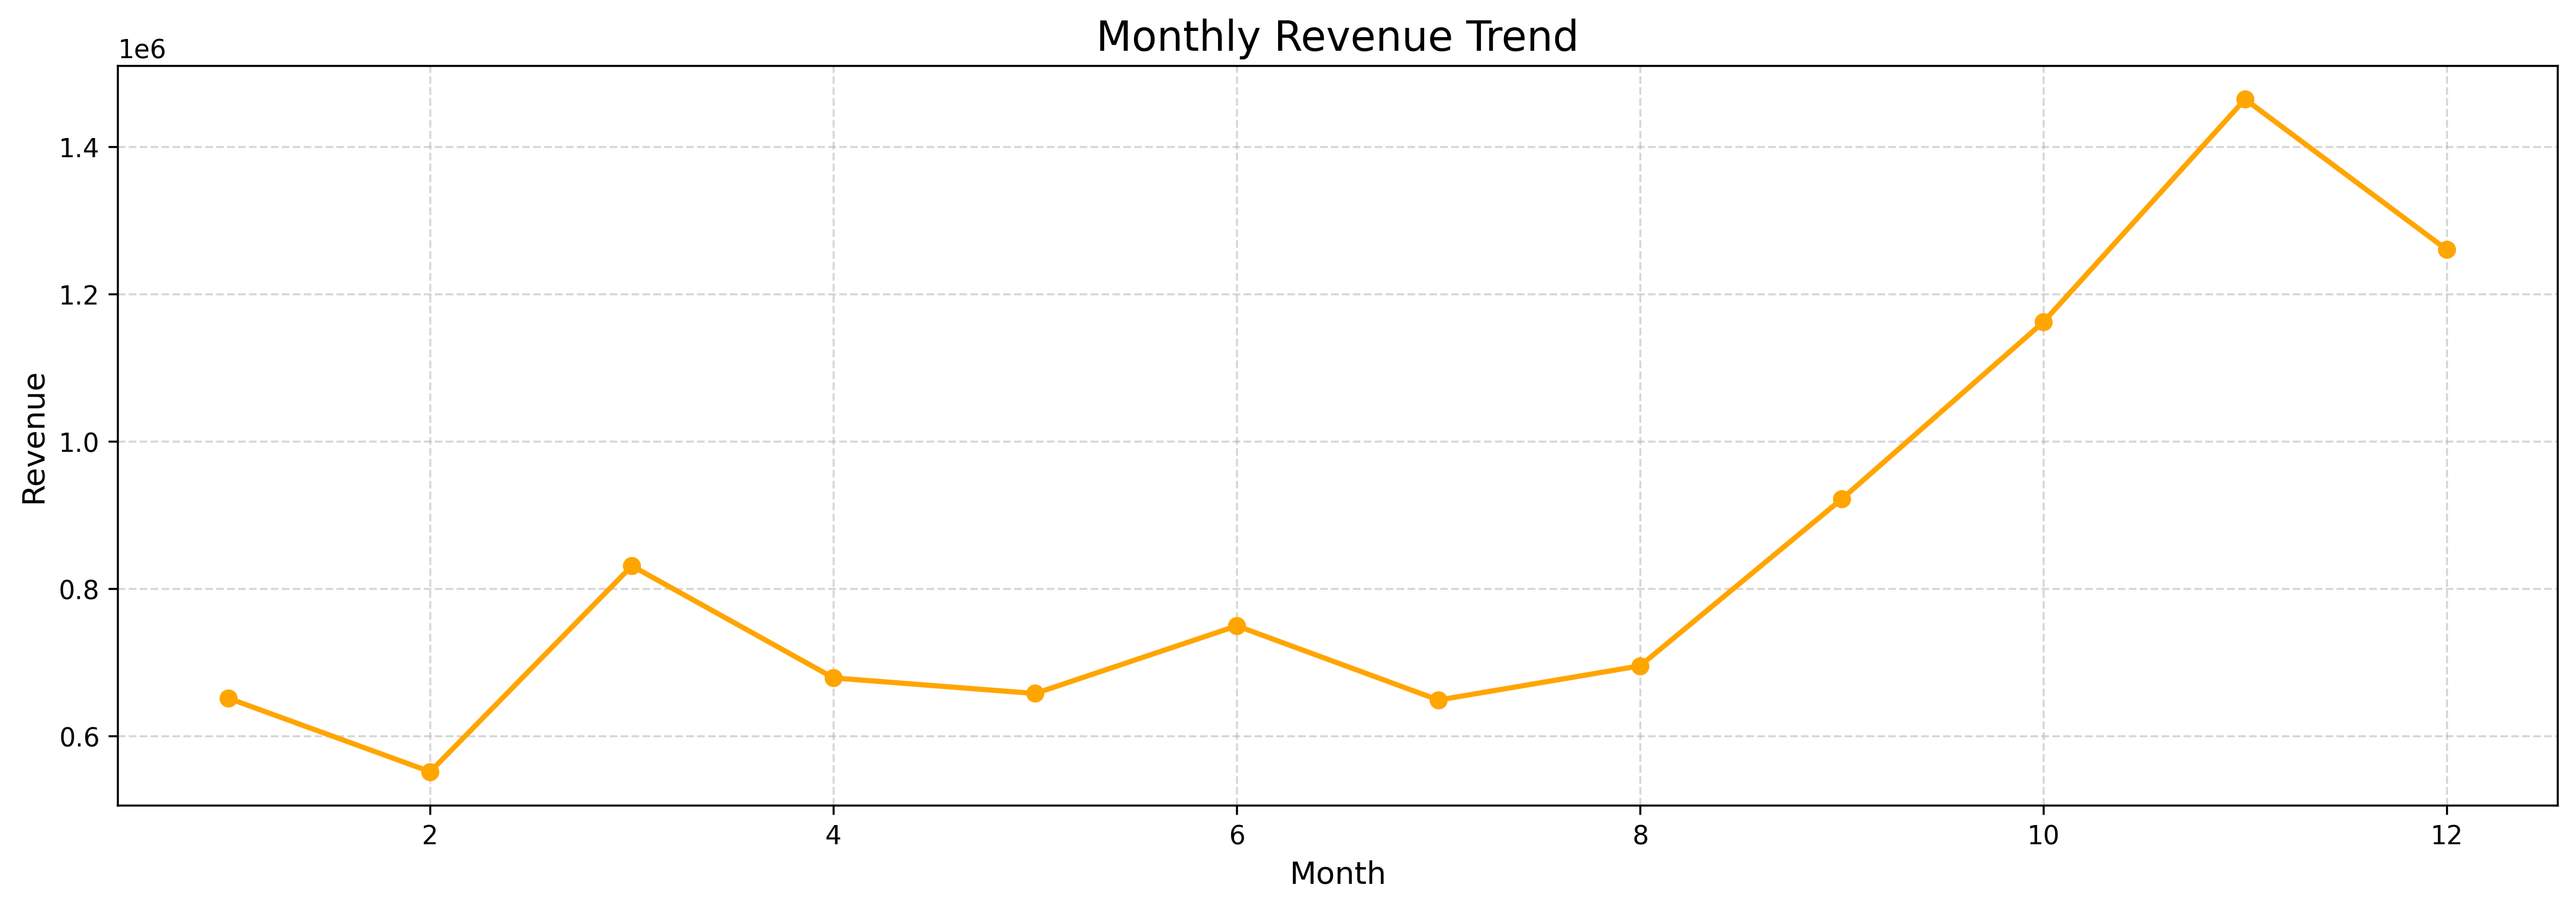

In [66]:
from IPython.display import Image
Image("report_figures/monthly_revenue_trend.png")

In [68]:
shutil.make_archive("notebook1_figures", 'zip', "report_figures")
from google.colab import files
files.download("notebook1_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>